# Step 4 – Results Plotting — QEC Codes & RHG Lattices

Loads completed results from `simulations_data/step4_results/` (QEC) and `simulations_data/step4_results_rhg/` (RHG), then produces a detailed presentation and analysis of the simulation data.

In [31]:
import pickle
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from IPython.display import display

# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR = pathlib.Path(
    "/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation"
    "/simulations_data/step4_results"
)
DB_DIR = pathlib.Path("graphs_database_paul")

ALGOS       = ["lrw_fix_bug", "lrw_sa", "path_clust", "saminla"]
ALGO_LABELS = {
    "lrw_fix_bug":        "hill_climbing",
    "lrw_sa":     "height_function_sa",
    "path_clust": "path_clustering",
    "saminla":    "min_la_sa",
}
ALGO_COLORS = ["#FF9800", "#9C27B0", "#2196F3", "#4CAF50"]

# ── Load all graphs from DB, merge with any available results ───────────────
rows = []
for graph_pkl in sorted(DB_DIR.glob("*.pkl")):
    graph_name = graph_pkl.stem
    with open(graph_pkl, "rb") as f:
        g: nx.Graph = pickle.load(f)
    n_vertices = g.number_of_nodes()
    n_edges    = g.number_of_edges()

    stem_dir = RESULTS_DIR / graph_name
    for algo in ALGOS:
        res_pkl = stem_dir / f"{algo}.pkl"
        if res_pkl.exists():
            with open(res_pkl, "rb") as f:
                res = pickle.load(f)
            rows.append({
                "graph":    graph_name,
                "algo":     algo,
                "vertices": n_vertices,
                "edges":    n_edges,
                "emitters": res.get("emitters"),
                "cnots":    res.get("cnots"),
                "gates":    res.get("gates"),
                "status":   "done",
            })
        else:
            rows.append({
                "graph":    graph_name,
                "algo":     algo,
                "vertices": n_vertices,
                "edges":    n_edges,
                "emitters": float("nan"),
                "cnots":    float("nan"),
                "gates":    float("nan"),
                "status":   "pending",
            })

df = pd.DataFrame(rows)

# Graphs where every algorithm has a result
all_graphs_sorted = sorted(df["graph"].unique())
done_set = {
    g for g in all_graphs_sorted
    if df[df["graph"] == g]["status"].eq("done").all()
}
df_done = df[df["graph"].isin(done_set)].copy()

n_total   = len(all_graphs_sorted)
n_done    = len(done_set)
n_pending = n_total - n_done
print(f"QEC database : {n_total} graphs  |  {n_done} fully done  |  {n_pending} still pending")
df_done.head(8)


QEC database : 55 graphs  |  40 fully done  |  15 still pending


,graph,algo,vertices,edges,emitters,cnots,gates,status
0,"bell_bb_code_[[108,8,10]]",lrw_fix_bug,216,15014,92.0,9085.0,16323.0,done
1,"bell_bb_code_[[108,8,10]]",lrw_sa,216,15014,83.0,9165.0,16980.0,done
2,"bell_bb_code_[[108,8,10]]",path_clust,216,15014,83.0,9165.0,16980.0,done
3,"bell_bb_code_[[108,8,10]]",saminla,216,15014,84.0,8713.0,15530.0,done
4,"bell_bb_code_[[144, 12, 12]]",lrw_fix_bug,288,28888,96.0,13941.0,25242.0,done
5,"bell_bb_code_[[144, 12, 12]]",lrw_sa,288,28888,102.0,14617.0,26590.0,done
6,"bell_bb_code_[[144, 12, 12]]",path_clust,288,28888,102.0,14617.0,26590.0,done
7,"bell_bb_code_[[144, 12, 12]]",saminla,288,28888,98.0,13598.0,23192.0,done


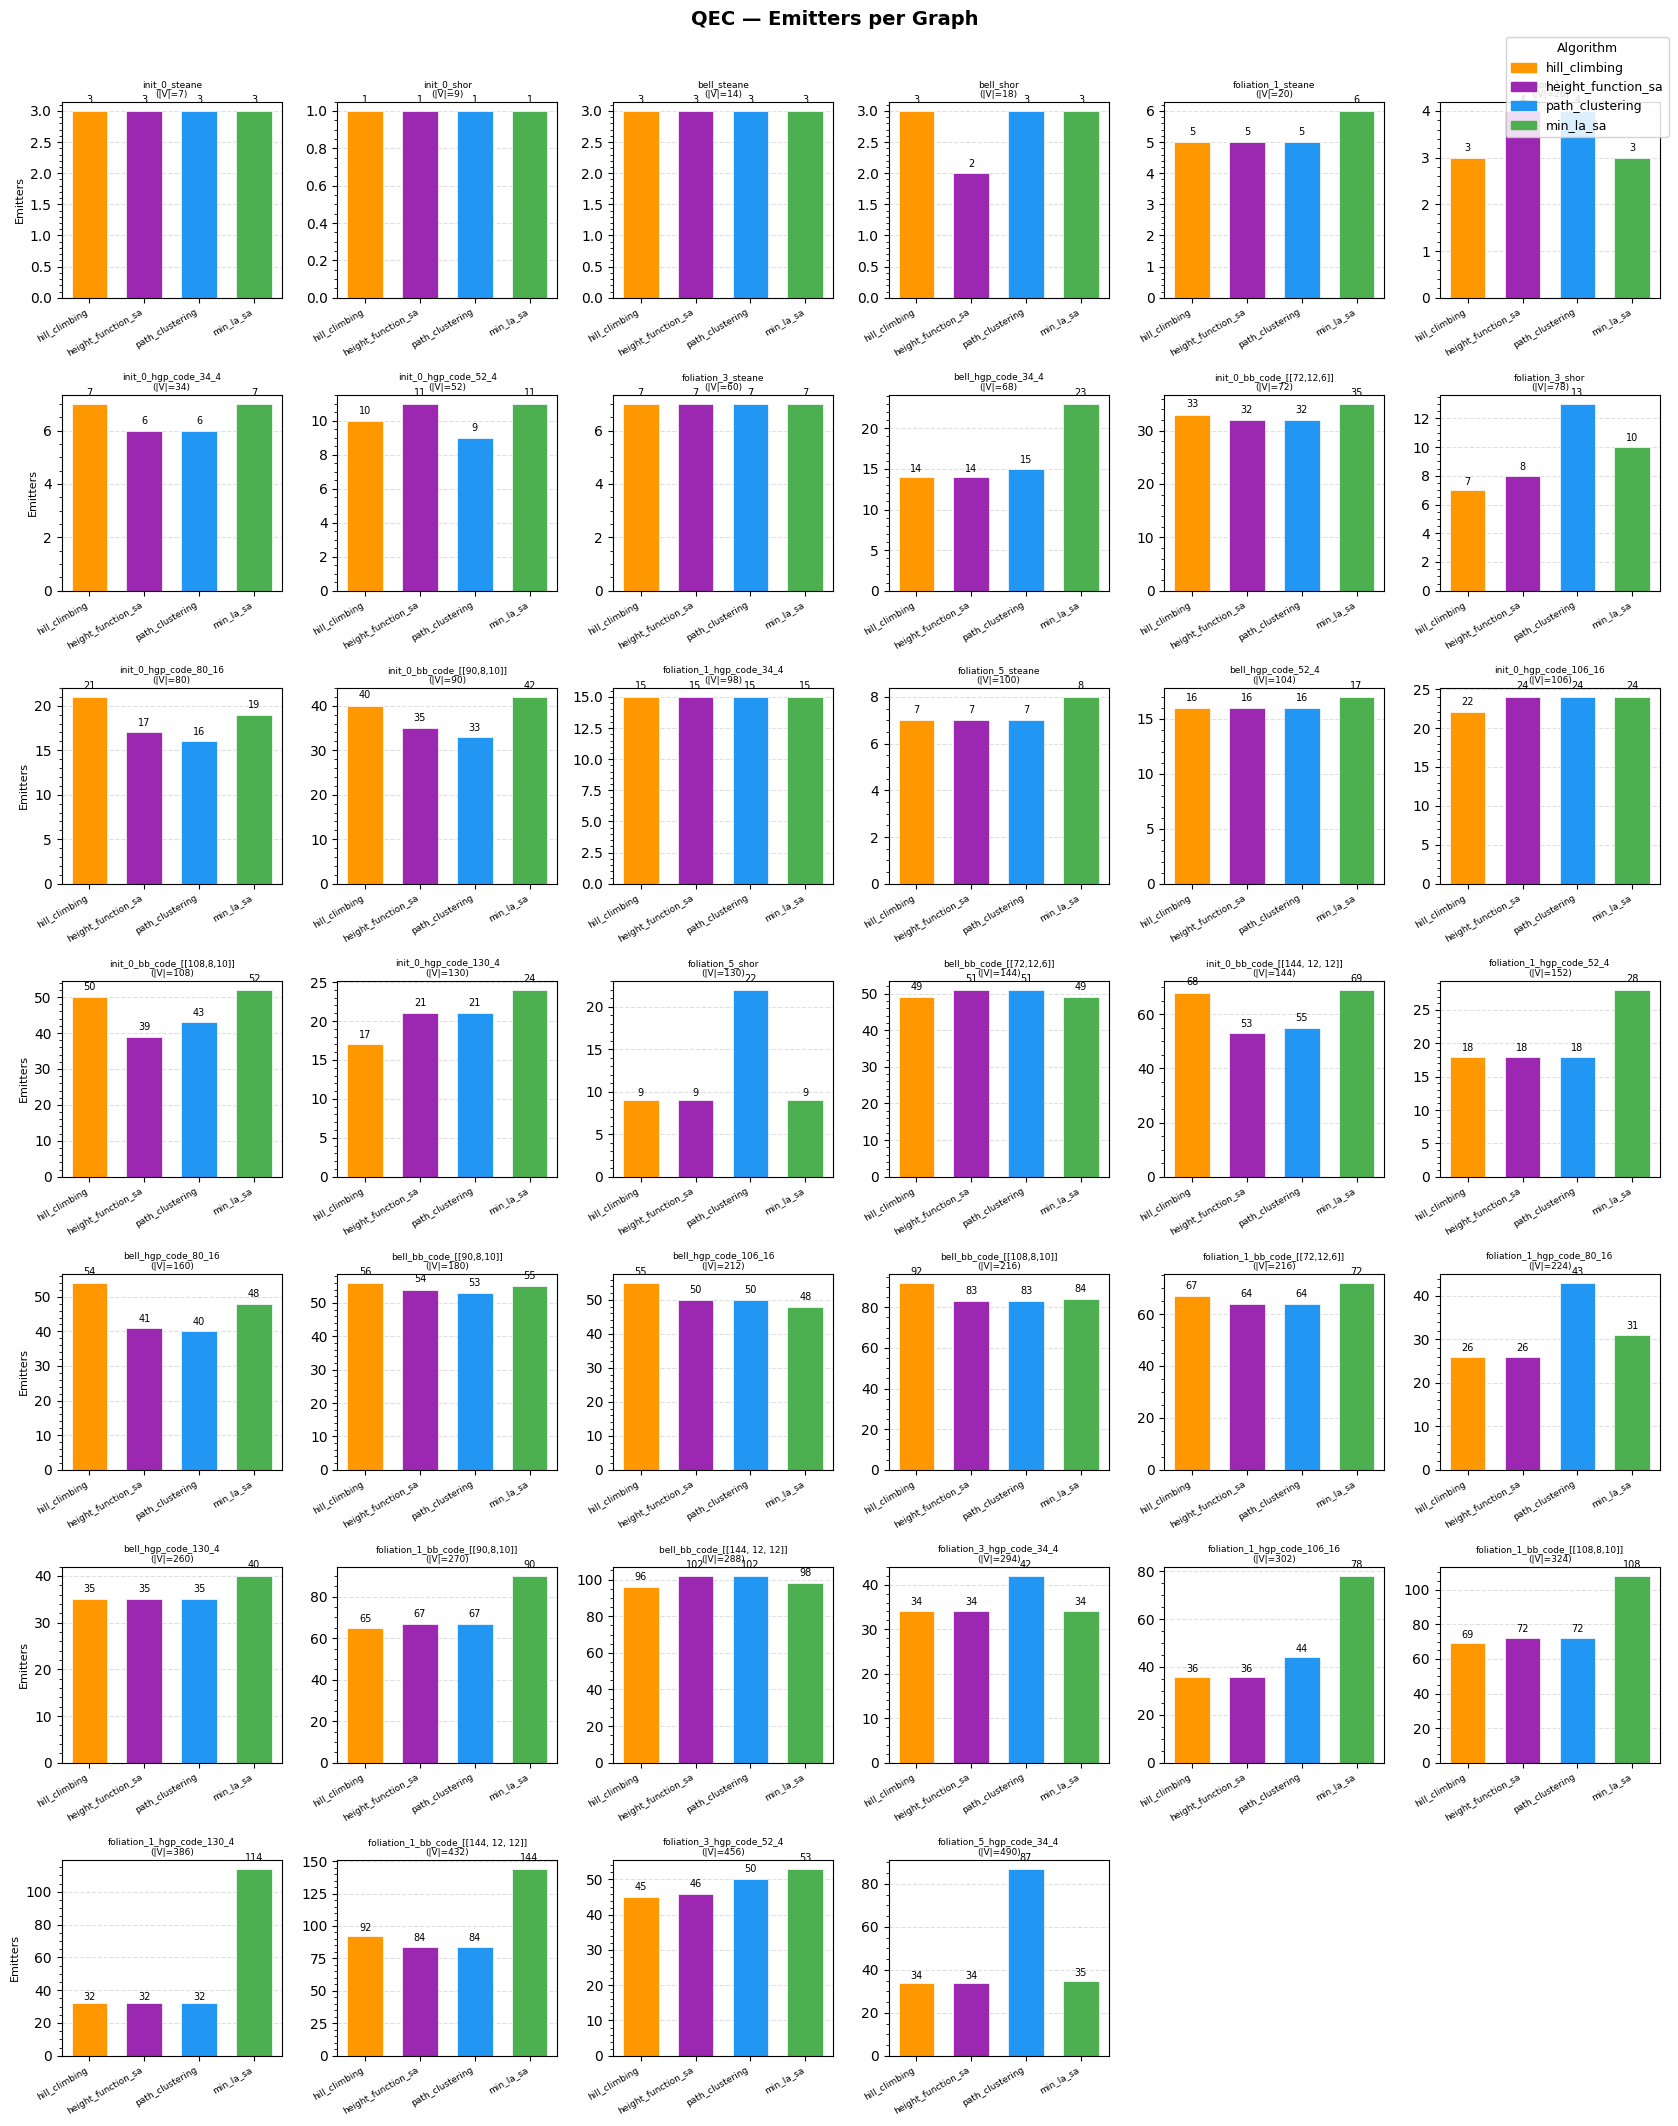

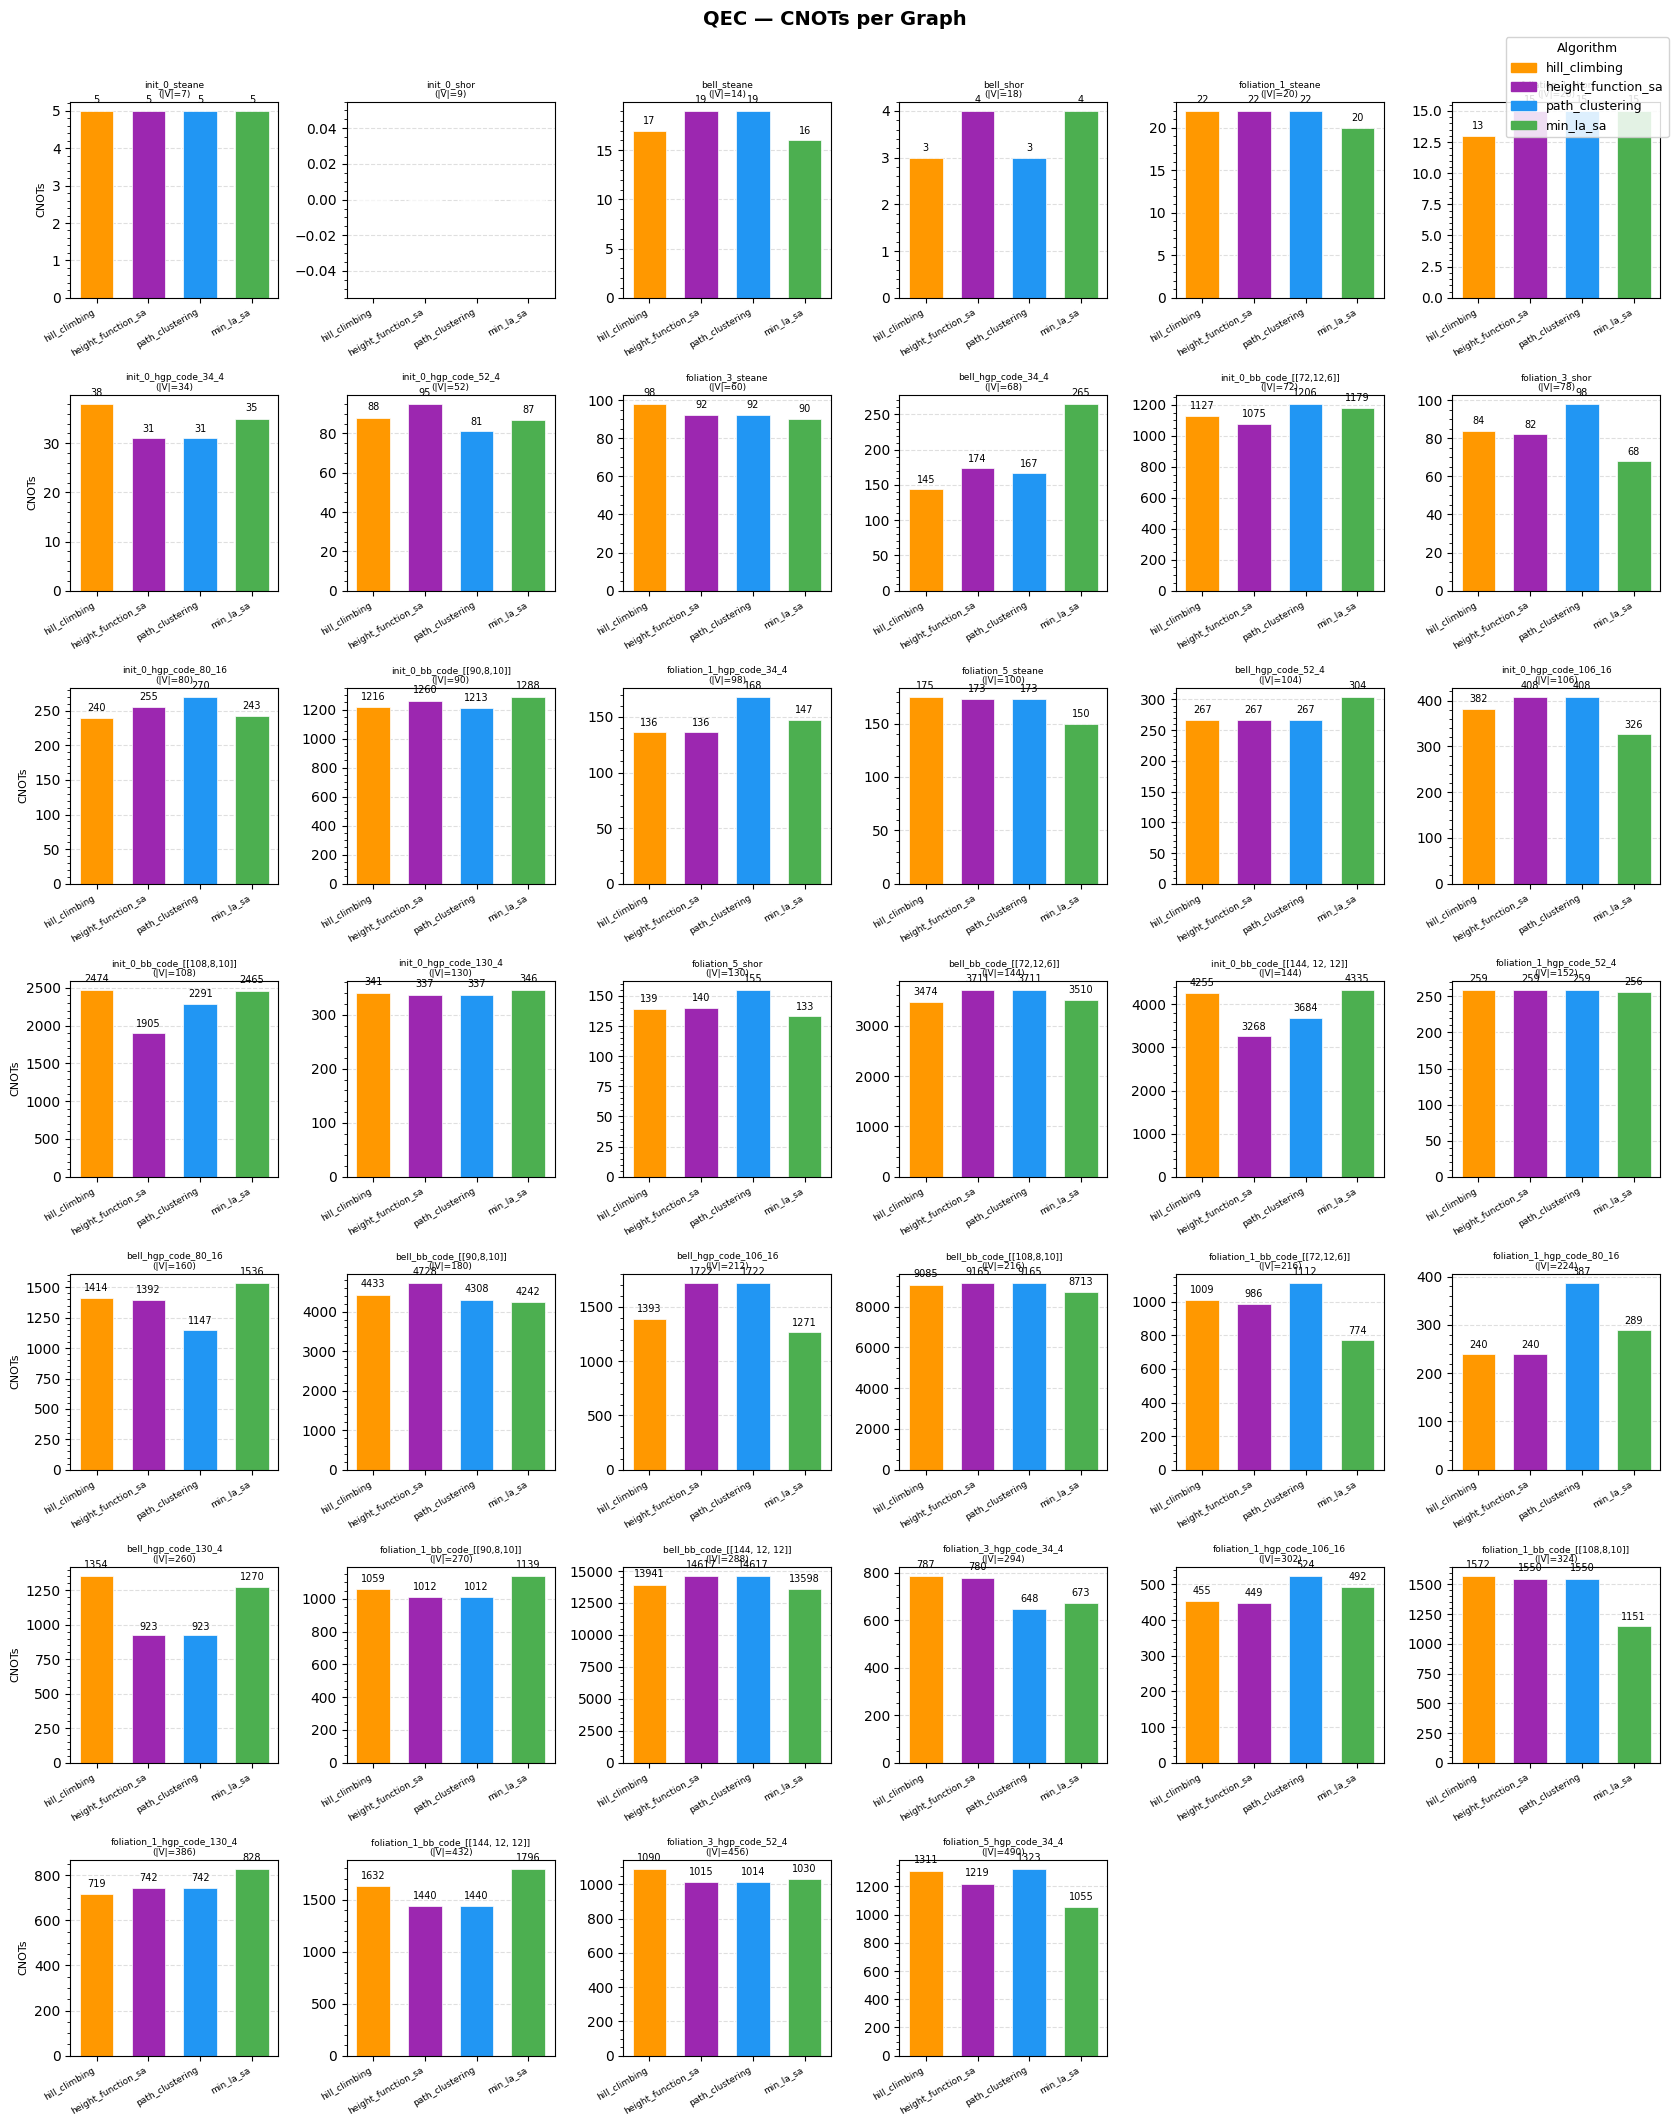

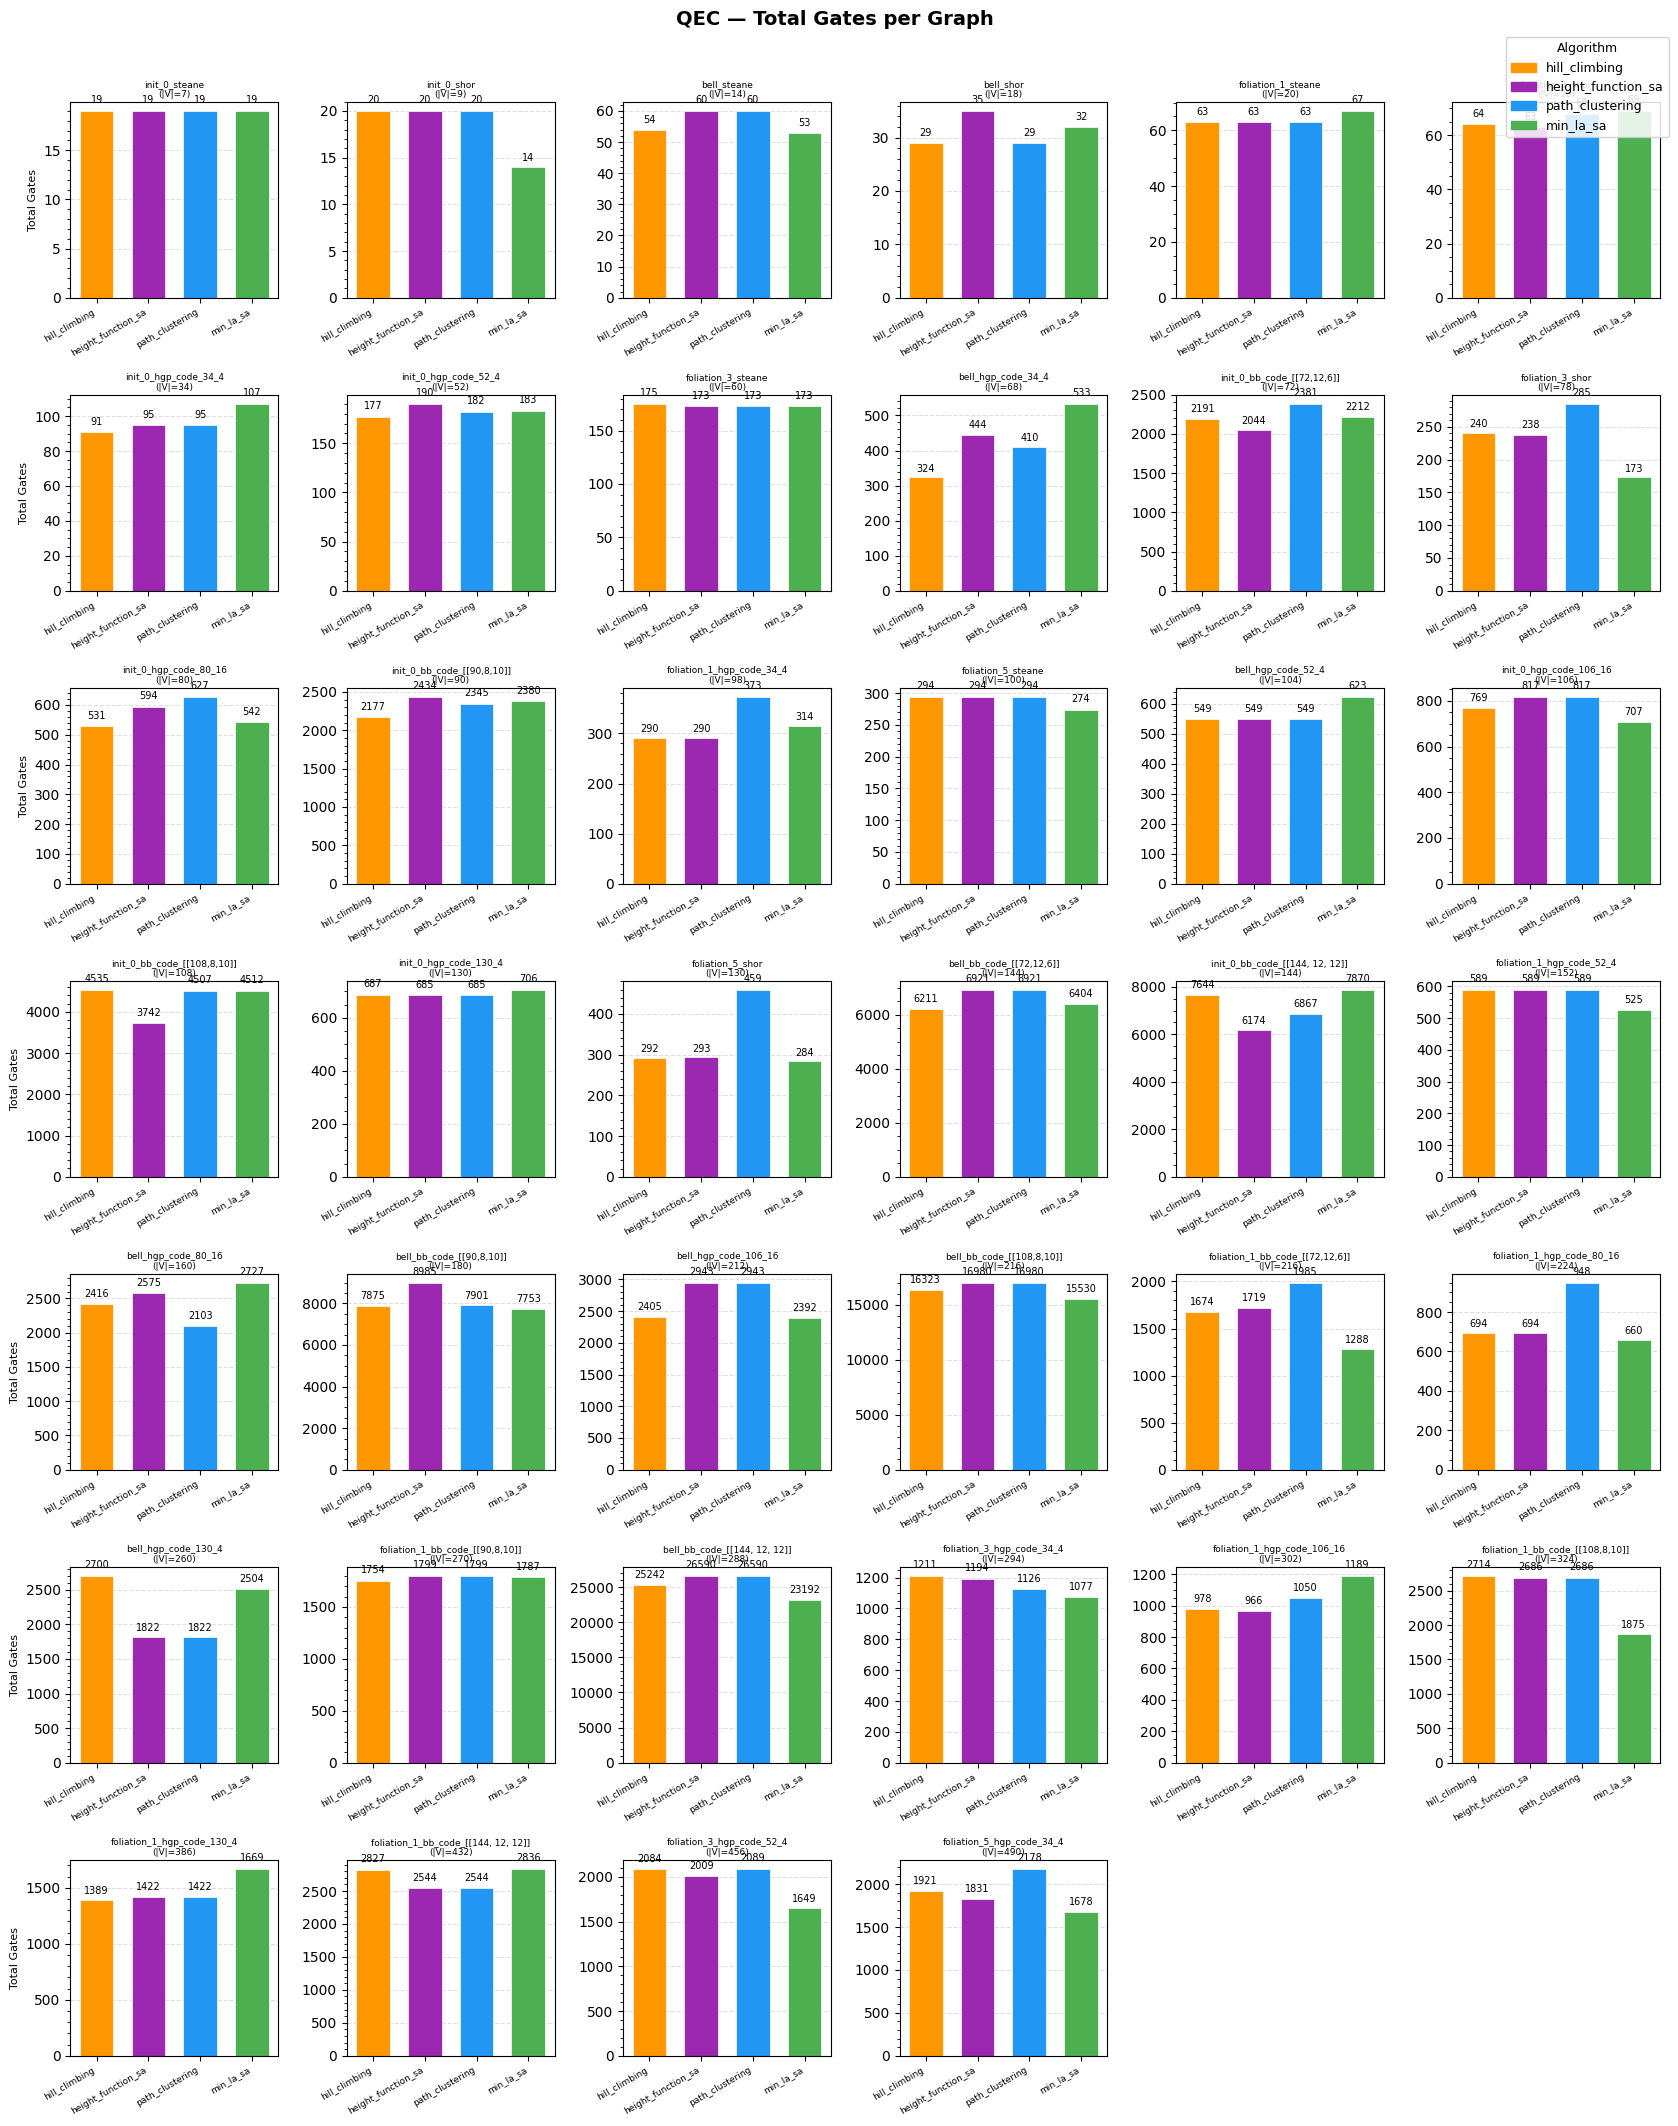

In [32]:
# ── Metric bar charts — one subplot per completed graph ─────────────────────
# Each subplot has its own y-scale so small graphs are not dwarfed by large ones.

def plot_metric_per_graph(df_in: pd.DataFrame, metric: str,
                          ylabel: str, title: str) -> None:
    """
    One subplot per completed graph, sorted by vertex count.
    Within each subplot the four algorithm bars share a common y-axis
    (auto-scaled to that graph's values), eliminating the scale problem.
    """
    # sort graphs by vertex count for a consistent left-to-right ordering
    order = (
        df_in[df_in["status"] == "done"][["graph", "vertices"]]
        .drop_duplicates()
        .sort_values("vertices")["graph"]
        .tolist()
    )
    if not order:
        print(f"No completed data for '{metric}'.")
        return

    n_graphs  = len(order)
    ncols     = min(6, n_graphs)
    nrows     = int(np.ceil(n_graphs / ncols))
    bw        = 0.18
    x         = np.arange(len(ALGOS))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 2.8, nrows * 3.0),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for idx, graph_name in enumerate(order):
        row_i, col_i = divmod(idx, ncols)
        ax = axes[row_i][col_i]

        sub = df_in[(df_in["graph"] == graph_name) & (df_in["status"] == "done")]
        vals = []
        for algo in ALGOS:
            row = sub[sub["algo"] == algo]
            vals.append(float(row[metric].values[0]) if not row.empty and pd.notna(row[metric].values[0]) else 0.0)

        bars = ax.bar(x, vals, width=0.65,
                      color=ALGO_COLORS, edgecolor="white", linewidth=0.5)

        # annotate value above each bar
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, v * 1.03,
                        str(int(v)), ha="center", va="bottom", fontsize=7)

        n_v = int(sub["vertices"].values[0]) if not sub.empty else "?"
        ax.set_title(f"{graph_name}\n(|V|={n_v})", fontsize=6.5, pad=3)
        ax.set_xticks(x)
        ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS],
                           rotation=30, ha="right", fontsize=6.5)
        ax.set_ylabel(ylabel if col_i == 0 else "", fontsize=8)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(axis="y", which="major", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

    # hide unused subplots
    for idx in range(n_graphs, nrows * ncols):
        row_i, col_i = divmod(idx, ncols)
        axes[row_i][col_i].set_visible(False)

    # shared legend
    handles = [mpatches.Patch(color=c, label=ALGO_LABELS[a])
               for a, c in zip(ALGOS, ALGO_COLORS)]
    fig.legend(handles=handles, title="Algorithm",
               loc="upper right", bbox_to_anchor=(1.0, 1.0),
               fontsize=9, title_fontsize=9, framealpha=0.85)

    plt.tight_layout()
    plt.show()


plot_metric_per_graph(df_done, "emitters", "Emitters",   "QEC — Emitters per Graph")
plot_metric_per_graph(df_done, "cnots",    "CNOTs",      "QEC — CNOTs per Graph")
plot_metric_per_graph(df_done, "gates",    "Total Gates","QEC — Total Gates per Graph")


## QEC Summary Table

One row per *(completed graph × algorithm)*, sorted by vertex count.
Columns: **Graph**, **|V|**, **|E|**, **Algorithm**, **Emitters**, **CNOTs**, **Gates**.

In [33]:
# ── QEC Summary Table (completed graphs only) ─────────────────────────────
table = (
    df_done[["graph", "vertices", "edges", "algo", "emitters", "cnots", "gates"]]
    .copy()
    .sort_values(["vertices", "graph", "algo"])
    .reset_index(drop=True)
)
table["algo"] = table["algo"].map(ALGO_LABELS)
for col in ["emitters", "cnots", "gates"]:
    table[col] = table[col].apply(lambda v: str(int(v)) if pd.notna(v) else "—")
table.columns = ["Graph", "|V|", "|E|", "Algorithm", "Emitters", "CNOTs", "Gates"]

styled = (
    table.style
    .set_caption(
        f"QEC Benchmark — {n_done} completed graphs × {len(ALGOS)} algorithms"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "4px 10px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background-color", "#f9f9f9")]},
    ])
)
display(styled)


,Graph,|V|,|E|,Algorithm,Emitters,CNOTs,Gates
0,init_0_steane,7,12,hill_climbing,3,5,19
1,init_0_steane,7,12,height_function_sa,3,5,19
2,init_0_steane,7,12,path_clustering,3,5,19
3,init_0_steane,7,12,min_la_sa,3,5,19
4,init_0_shor,9,6,hill_climbing,1,0,20
5,init_0_shor,9,6,height_function_sa,1,0,20
6,init_0_shor,9,6,path_clustering,1,0,20
7,init_0_shor,9,6,min_la_sa,1,0,14
8,bell_steane,14,33,hill_climbing,3,17,54
9,bell_steane,14,33,height_function_sa,3,19,60


## QEC — Algorithm Comparison

**Plot D** – For each metric, which algorithm achieves the minimum value on the most QEC graphs?

**Plot E** – Normalised radar chart: each algorithm's average rank (1 = best, 4 = worst) across all metrics and graphs.

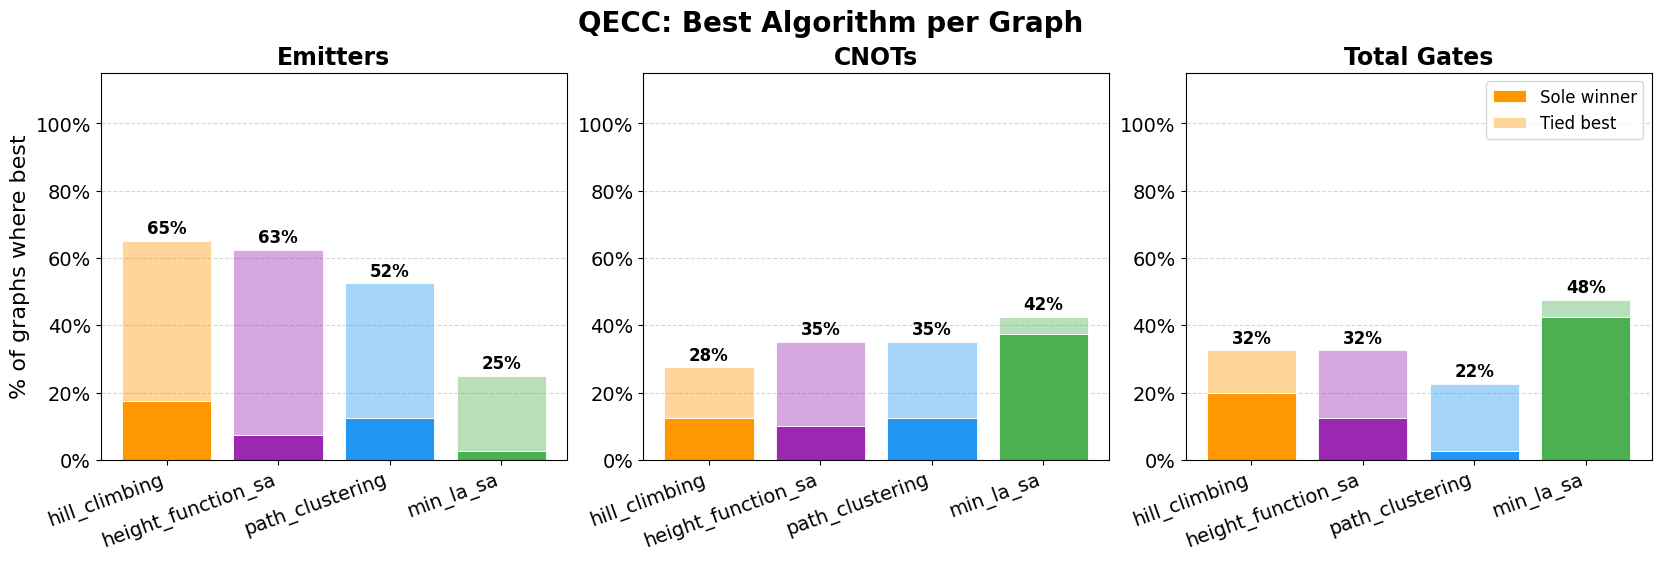

In [34]:
# ── Plot D  (QEC) — which algorithm wins most graphs per metric ───────────────

LABEL_SIZE = 16
TITLE_SIZE = 17
TICK_SIZE = 14
BAR_TEXT_SIZE = 12
LEGEND_SIZE = 12
SUPTITLE_SIZE = 20

METRICS_QEC = [
    ("emitters", "Emitters"),
    ("cnots",    "CNOTs"),
    ("gates",    "Total Gates"),
]

fig, axes = plt.subplots(
    1,
    len(METRICS_QEC),
    figsize=(5.5 * len(METRICS_QEC), 5.5),
    sharey=False,
    constrained_layout=True
)

fig.suptitle(
    "QECC: Best Algorithm per Graph",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold"
)

for ax, (metric, mlabel) in zip(axes, METRICS_QEC):
    wins = {a: 0 for a in ALGOS}
    ties = {a: 0 for a in ALGOS}
    n_compared = 0

    for graph_name in done_set:
        sub = df_done[df_done["graph"] == graph_name]

        vals = {
            row["algo"]: row[metric]
            for _, row in sub.iterrows()
            if pd.notna(row[metric])
        }

        if not vals:
            continue

        best = min(vals.values())

        winners = [
            a
            for a, v in vals.items()
            if v == best
        ]

        n_compared += 1

        for a in winners:
            if len(winners) == 1:
                wins[a] += 1
            else:
                ties[a] += 1

    pct_wins = [
        wins[a] / n_compared * 100 if n_compared else 0
        for a in ALGOS
    ]

    pct_ties = [
        ties[a] / n_compared * 100 if n_compared else 0
        for a in ALGOS
    ]

    x = np.arange(len(ALGOS))

    bars_w = ax.bar(
        x,
        pct_wins,
        color=ALGO_COLORS,
        edgecolor="white",
        linewidth=0.6,
        label="Sole winner"
    )

    bars_t = ax.bar(
        x,
        pct_ties,
        bottom=pct_wins,
        color=[c + "66" for c in ALGO_COLORS],
        edgecolor="white",
        linewidth=0.6,
        label="Tied best"
    )

    # annotations
    for bar, pw, pt in zip(bars_w, pct_wins, pct_ties):
        total = pw + pt

        if total > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                total + 1.0,
                f"{total:.0f}%",
                ha="center",
                va="bottom",
                fontsize=BAR_TEXT_SIZE,
                fontweight="bold"
            )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [ALGO_LABELS[a] for a in ALGOS],
        fontsize=TICK_SIZE,
        rotation=20,
        ha="right"
    )

    ax.set_title(
        mlabel,
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    ax.set_ylabel(
        "% of graphs where best" if ax == axes[0] else "",
        fontsize=LABEL_SIZE
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    ax.set_axisbelow(True)

    if ax == axes[-1]:
        ax.legend(
            fontsize=LEGEND_SIZE,
            loc="upper right"
        )

plt.show()

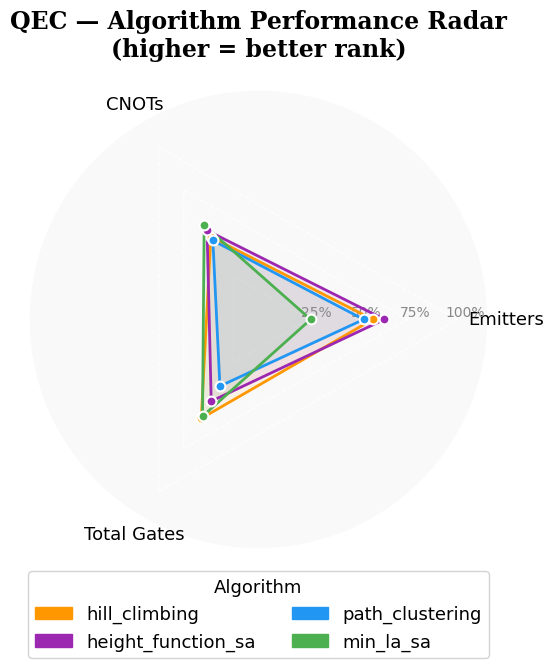

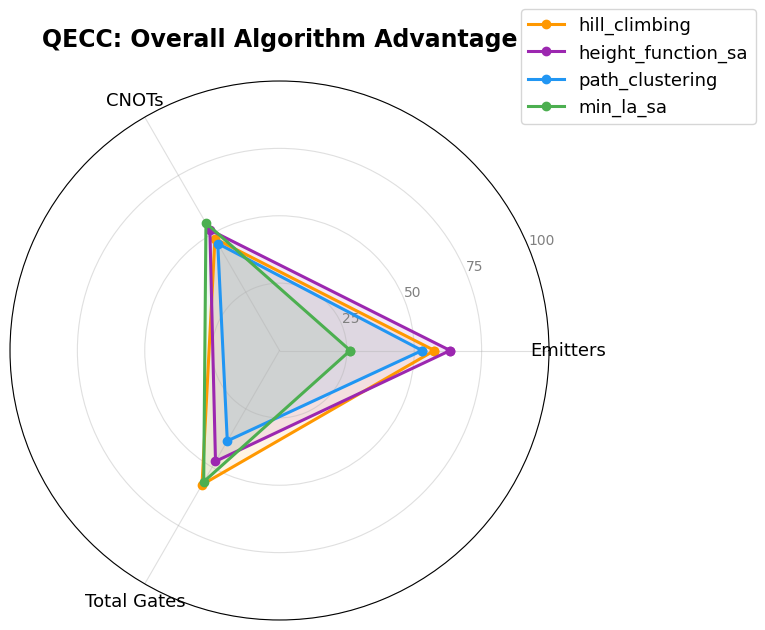

In [35]:
# ── Plot E  (QEC) — normalised radar chart ────────────────────────────────────
# For each graph×metric, rank algorithms 1–4. 1 = best. Average rank → radar.

import matplotlib
from matplotlib.patches import FancyArrowPatch

LABEL_SIZE = 15
TITLE_SIZE = 17
TICK_SIZE = 13
RADIAL_TICK_SIZE = 10
LEGEND_SIZE = 13
LEGEND_TITLE_SIZE = 13
REFERENCE_TEXT_SIZE = 10

radar_metrics = [m for m, _ in METRICS_QEC]
radar_labels = [l for _, l in METRICS_QEC]
N = len(radar_metrics)

# compute mean rank per algorithm per metric
rank_data = {a: [] for a in ALGOS}

for metric in radar_metrics:
    ranks_per_graph = []

    for graph_name in done_set:
        sub = df_done[df_done["graph"] == graph_name]

        vals = {
            row["algo"]: row[metric]
            for _, row in sub.iterrows()
            if pd.notna(row[metric])
        }

        if len(vals) < 2:
            continue

        sorted_algos = sorted(vals, key=lambda a: vals[a])

        rank_map = {}
        r = 1
        i = 0

        while i < len(sorted_algos):
            j = i

            while (
                j < len(sorted_algos) - 1
                and vals[sorted_algos[j + 1]] == vals[sorted_algos[j]]
            ):
                j += 1

            avg_r = (r + r + (j - i)) / 2

            for k in range(i, j + 1):
                rank_map[sorted_algos[k]] = avg_r

            r += (j - i + 1)
            i = j + 1

        ranks_per_graph.append(rank_map)

    for a in ALGOS:
        arr = [
            rg[a]
            for rg in ranks_per_graph
            if a in rg
        ]

        rank_data[a].append(
            np.mean(arr) if arr else np.nan
        )

# Normalise: 1 = best → 100%, 4 = worst → 0%
# so larger = better on radar
def rank_to_score(rank):
    return (4 - rank) / 3 * 100


# ═══════════════════════════════════════════════════════════════════
# Radar plot 1 — custom styled version
# ═══════════════════════════════════════════════════════════════════

angles = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(
    figsize=(7, 7),
    facecolor="white"
)

ax = fig.add_subplot(
    111,
    polar=True
)

ax.set_facecolor("#F9F9F9")

# reference rings
for ref in [25, 50, 75, 100]:
    ax.plot(
        angles,
        [ref] * (N + 1),
        color="white",
        linewidth=0.8,
        linestyle="--",
        zorder=1
    )

    ax.text(
        0,
        ref + 4,
        f"{ref}%",
        ha="center",
        va="bottom",
        fontsize=REFERENCE_TEXT_SIZE,
        color="#888888"
    )

ax.set_thetagrids(
    np.degrees(angles[:-1]),
    radar_labels,
    fontsize=LABEL_SIZE
)

ax.tick_params(
    axis="x",
    labelsize=TICK_SIZE
)

ax.set_ylim(0, 115)
ax.set_yticks([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

for a, color in zip(ALGOS, ALGO_COLORS):
    scores = [
        rank_to_score(r)
        for r in rank_data[a]
    ]

    scores += scores[:1]

    ax.plot(
        angles,
        scores,
        color=color,
        linewidth=2,
        zorder=3
    )

    ax.fill(
        angles,
        scores,
        color=color,
        alpha=0.08,
        zorder=2
    )

    ax.scatter(
        angles[:-1],
        scores[:-1],
        color=color,
        s=50,
        zorder=4,
        edgecolors="white",
        linewidths=1.5
    )

ax.set_title(
    "QEC — Algorithm Performance Radar\n(higher = better rank)",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=25,
    fontfamily="serif"
)

handles = [
    mpatches.Patch(
        color=c,
        label=ALGO_LABELS[a]
    )
    for a, c in zip(ALGOS, ALGO_COLORS)
]

ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.26),
    ncol=2,
    fontsize=LEGEND_SIZE,
    framealpha=0.85,
    title="Algorithm",
    title_fontsize=LEGEND_TITLE_SIZE
)

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════
# Radar plot 2 — standard style matching original Plot E
# ═══════════════════════════════════════════════════════════════════

N_qec = len(radar_labels)

angles_qec = np.linspace(
    0,
    2 * np.pi,
    N_qec,
    endpoint=False
).tolist()

angles_qec += angles_qec[:1]

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw=dict(polar=True)
)

for a, color in zip(ALGOS, ALGO_COLORS):
    scores = [
        rank_to_score(r) if not np.isnan(r) else 0
        for r in rank_data[a]
    ]

    scores += scores[:1]

    ax.plot(
        angles_qec,
        scores,
        color=color,
        linewidth=2.2,
        label=ALGO_LABELS[a],
        marker="o",
        markersize=6
    )

    ax.fill(
        angles_qec,
        scores,
        color=color,
        alpha=0.10
    )

ax.set_xticks(
    angles_qec[:-1]
)

ax.set_xticklabels(
    radar_labels,
    fontsize=LABEL_SIZE
)

ax.tick_params(
    axis="x",
    labelsize=TICK_SIZE
)

ax.set_ylim(
    0,
    100
)

ax.set_yticks(
    [25, 50, 75, 100]
)

ax.set_yticklabels(
    ["25", "50", "75", "100"],
    fontsize=RADIAL_TICK_SIZE,
    color="grey"
)

ax.tick_params(
    axis="y",
    labelsize=RADIAL_TICK_SIZE
)

ax.set_title(
    "QECC: Overall Algorithm Advantage",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.40, 1.15),
    fontsize=LEGEND_SIZE
)

ax.grid(
    True,
    alpha=0.4
)

plt.show()

# RHG Lattice Results

Loads completed results from `simulations_data/step4_results_rhg/` for the 20 RHG lattices
(`RGH_x_y_z`, 18 – 540 vertices). Shows per-graph metric charts, a summary table, and
algorithm comparison (Plot D + E style).

In [36]:
import pickle
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display

# ── Paths ──────────────────────────────────────────────────────────────────
RHG_DB_DIR      = pathlib.Path("step4_rgh_database")
RHG_RESULTS_DIR = pathlib.Path(
    "/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation"
    "/simulations_data/step4_results_rhg"
)

ALGOS_RHG = ["lrw_fix_bug", "lrw_sa", "path_clust", "saminla"]
ALGO_LABELS_RHG = {
    "lrw_fix_bug":        "hill_climbing",
    "lrw_sa":     "height_function_sa",
    "path_clust": "path_clustering",
    "saminla":    "min_la_sa",
}
ALGO_COLORS_RHG = ["#FF9800", "#9C27B0", "#2196F3", "#4CAF50"]

# ── Build dataframe from DB + any available results ─────────────────────────
def load_rhg_dataframe() -> pd.DataFrame:
    rows = []
    for graph_pkl in sorted(RHG_DB_DIR.glob("*.pkl")):
        graph_name = graph_pkl.stem
        with open(graph_pkl, "rb") as f:
            g = pickle.load(f)
        n_v = g.number_of_nodes()
        n_e = g.number_of_edges()
        parts = graph_name.replace("RGH_", "").split("_")
        dims  = tuple(int(p) for p in parts) if len(parts) == 3 else ("?", "?", "?")

        stem_dir = RHG_RESULTS_DIR / graph_name
        for algo in ALGOS_RHG:
            res_pkl = stem_dir / f"{algo}.pkl"
            if res_pkl.exists():
                with open(res_pkl, "rb") as f:
                    res = pickle.load(f)
                rows.append({
                    "graph":     graph_name,
                    "dims":      dims,
                    "algo":      algo,
                    "vertices":  n_v,
                    "edges":     n_e,
                    "emitters":  res.get("emitters"),
                    "cnots":     res.get("cnots"),
                    "gates":     res.get("gates"),
                    "runtime_s": res.get("runtime_s"),
                    "status":    "done",
                })
            else:
                rows.append({
                    "graph":     graph_name,
                    "dims":      dims,
                    "algo":      algo,
                    "vertices":  n_v,
                    "edges":     n_e,
                    "emitters":  float("nan"),
                    "cnots":     float("nan"),
                    "gates":     float("nan"),
                    "runtime_s": float("nan"),
                    "status":    "pending",
                })
    return pd.DataFrame(rows)


df_rhg = load_rhg_dataframe()

all_rhg_graphs = sorted(df_rhg["graph"].unique())
done_graphs_rhg = {
    g for g in all_rhg_graphs
    if df_rhg[df_rhg["graph"] == g]["status"].eq("done").all()
}
df_rhg_done = df_rhg[df_rhg["graph"].isin(done_graphs_rhg)].copy()

n_total_rhg   = len(all_rhg_graphs)
n_done_rhg    = len(done_graphs_rhg)
n_pending_rhg = n_total_rhg - n_done_rhg

print(f"RHG database : {n_total_rhg} graphs  |  {n_done_rhg} fully done  |  {n_pending_rhg} still pending")
df_rhg_done.head(8)


RHG database : 20 graphs  |  19 fully done  |  1 still pending


,graph,dims,algo,vertices,edges,emitters,cnots,gates,runtime_s,status
0,RGH_1_1_1,"(1, 1, 1)",lrw_fix_bug,18,24,4.0,14.0,40.0,2.973564,done
1,RGH_1_1_1,"(1, 1, 1)",lrw_sa,18,24,4.0,14.0,40.0,5.913671,done
2,RGH_1_1_1,"(1, 1, 1)",path_clust,18,24,4.0,14.0,40.0,4.574883,done
3,RGH_1_1_1,"(1, 1, 1)",saminla,18,24,4.0,15.0,45.0,1.689383,done
4,RGH_1_1_2,"(1, 1, 2)",lrw_fix_bug,31,44,4.0,30.0,73.0,6.274628,done
5,RGH_1_1_2,"(1, 1, 2)",lrw_sa,31,44,4.0,30.0,73.0,12.597509,done
6,RGH_1_1_2,"(1, 1, 2)",path_clust,31,44,4.0,30.0,73.0,9.352044,done
7,RGH_1_1_2,"(1, 1, 2)",saminla,31,44,5.0,30.0,70.0,3.344145,done


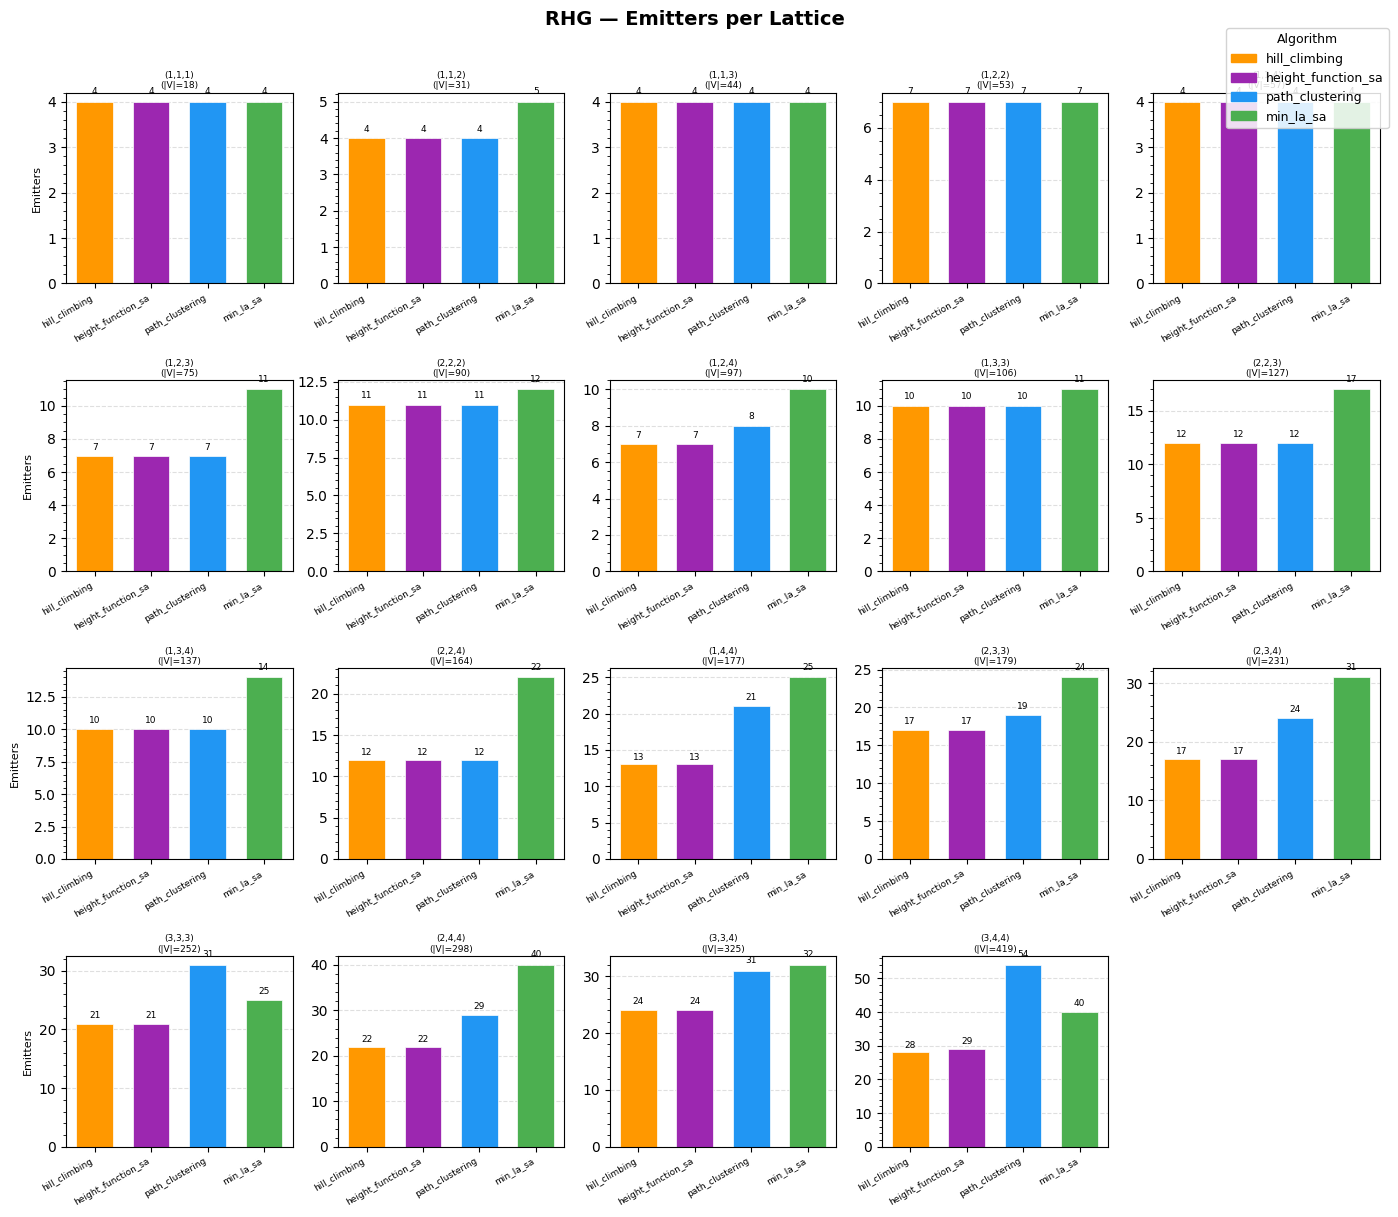

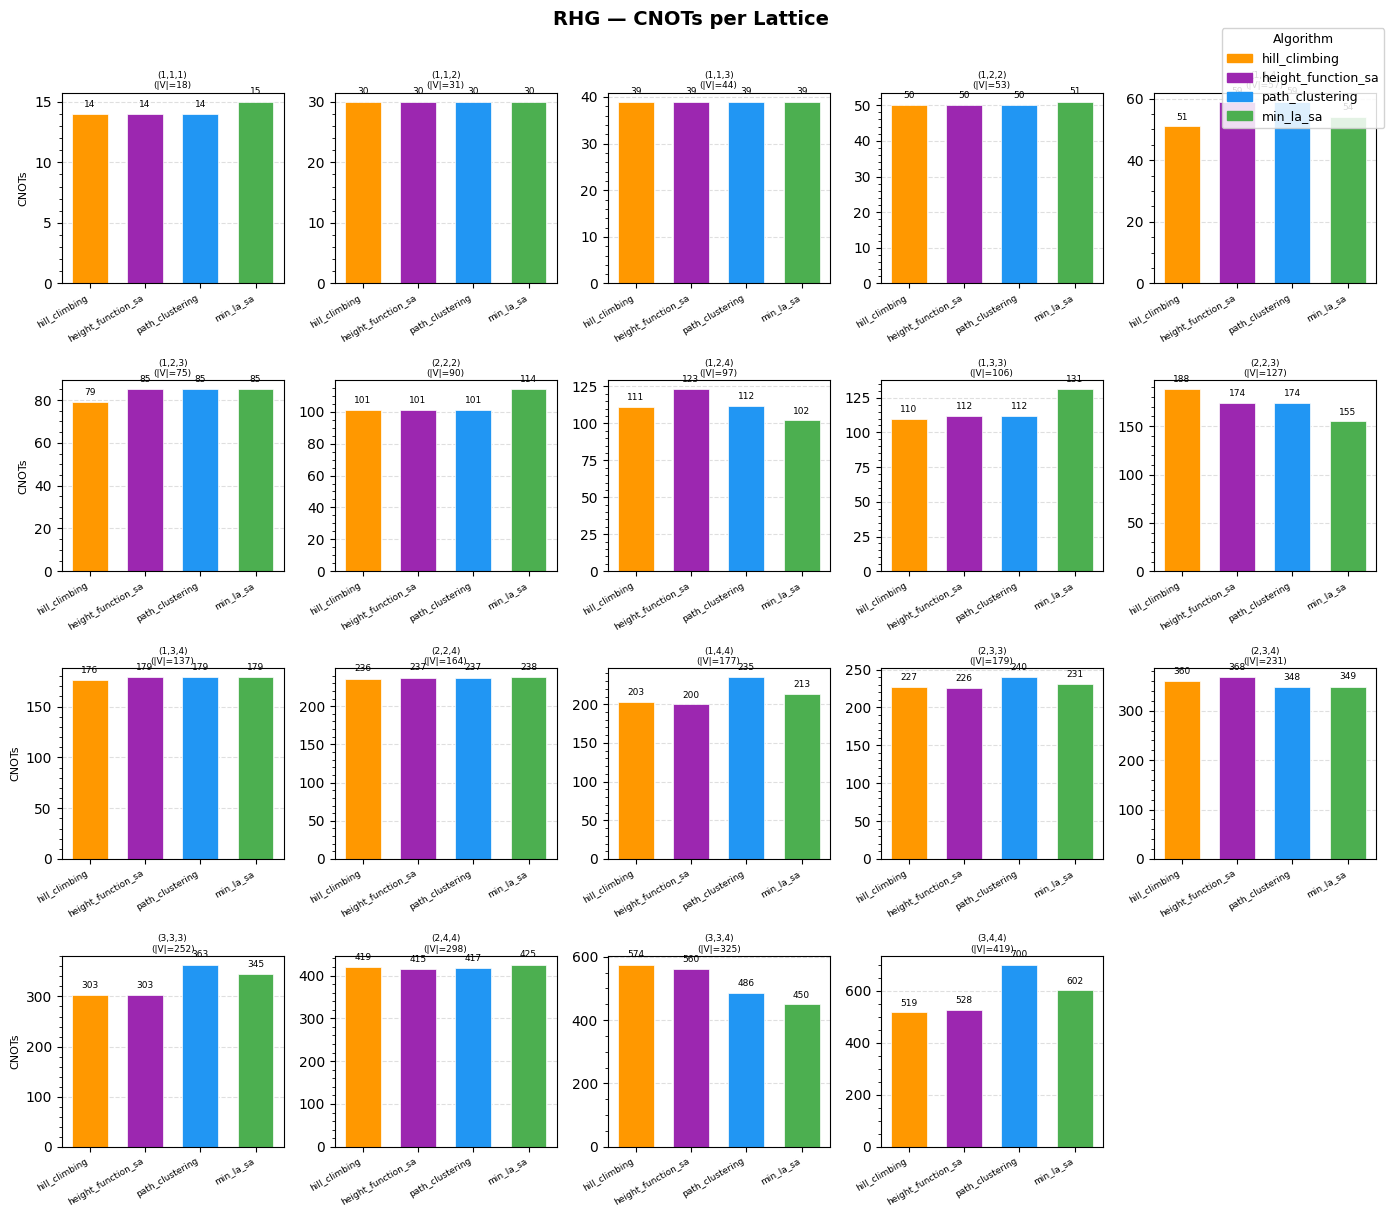

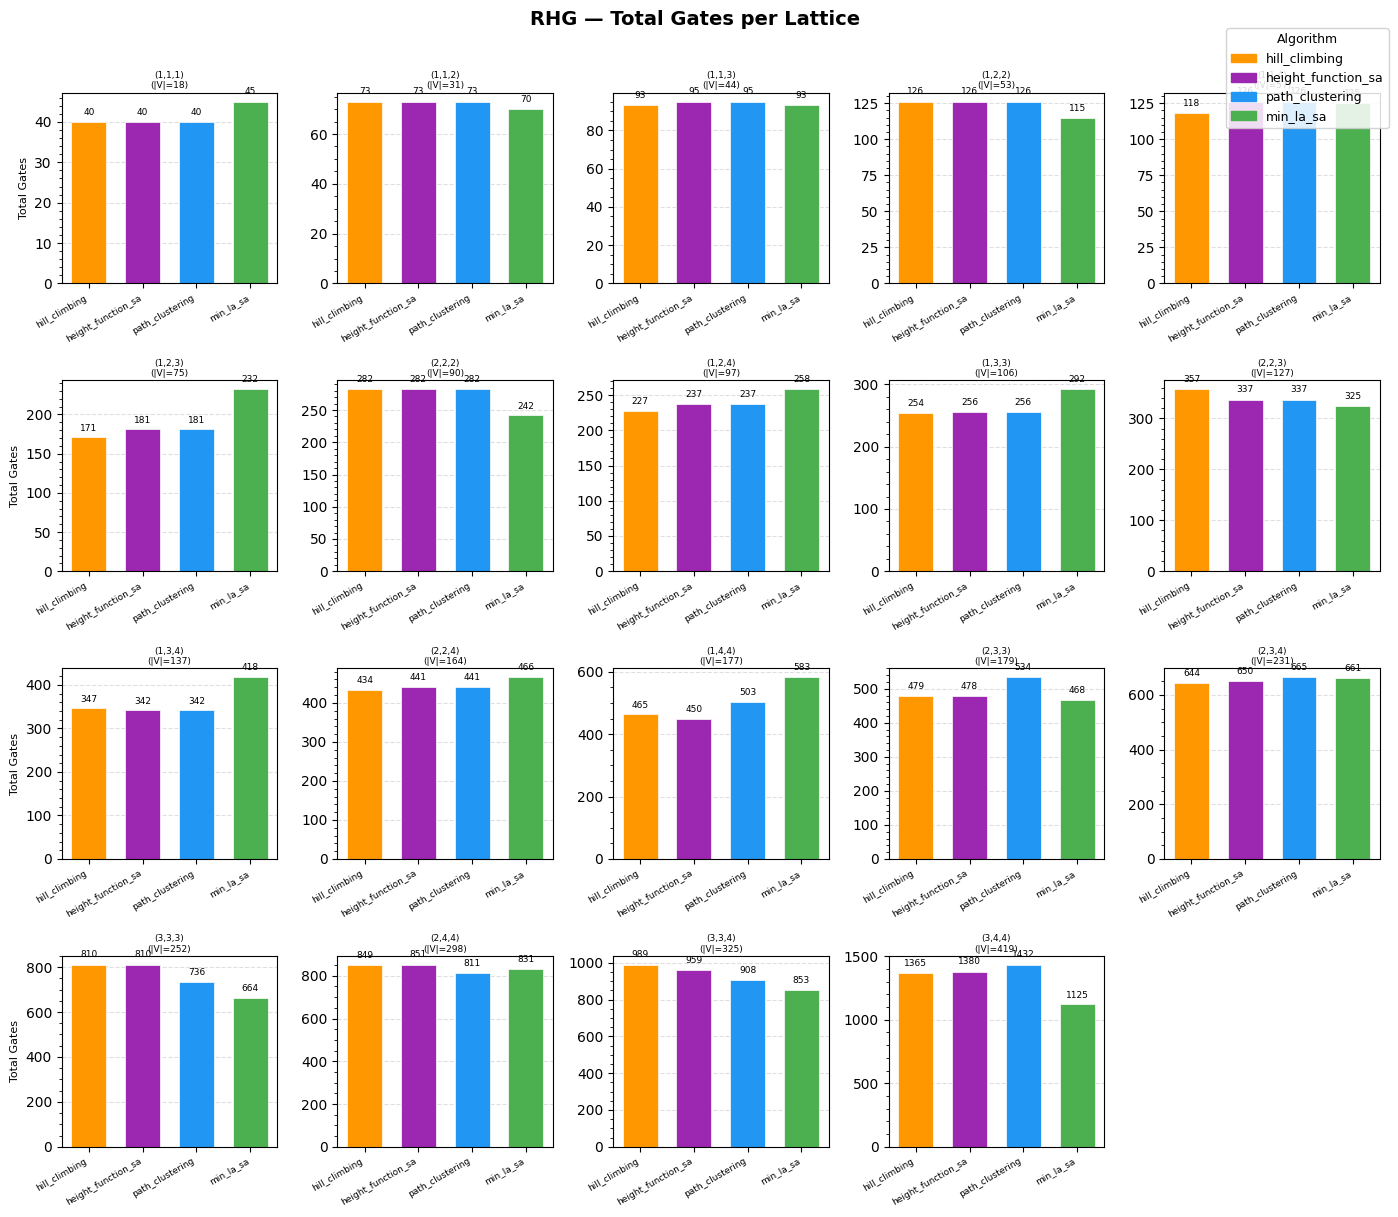

In [37]:
# ── RHG Metric charts — one subplot per completed graph ──────────────────────
def plot_rhg_metric_per_graph(df_in: pd.DataFrame, metric: str,
                               ylabel: str, title: str) -> None:
    """
    One subplot per completed RHG graph, sorted by vertex count.
    Each subplot uses its own y-scale to handle the wide range of lattice sizes.
    """
    order = (
        df_in[df_in["status"] == "done"][["graph", "vertices"]]
        .drop_duplicates()
        .sort_values("vertices")["graph"]
        .tolist()
    )
    if not order:
        print(f"No completed data for '{metric}'.")
        return

    n_graphs = len(order)
    ncols    = min(5, n_graphs)
    nrows    = int(np.ceil(n_graphs / ncols))
    x        = np.arange(len(ALGOS_RHG))

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 2.8, nrows * 3.0),
                              squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for idx, graph_name in enumerate(order):
        row_i, col_i = divmod(idx, ncols)
        ax = axes[row_i][col_i]

        sub = df_in[(df_in["graph"] == graph_name) & (df_in["status"] == "done")]
        vals = []
        for algo in ALGOS_RHG:
            r = sub[sub["algo"] == algo]
            vals.append(float(r[metric].values[0]) if not r.empty and pd.notna(r[metric].values[0]) else 0.0)

        bars = ax.bar(x, vals, width=0.65,
                      color=ALGO_COLORS_RHG, edgecolor="white", linewidth=0.5)

        for bar, v in zip(bars, vals):
            if v > 0:
                fmt = f"{v:.0f}" if v >= 1 else f"{v:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, v * 1.03,
                        fmt, ha="center", va="bottom", fontsize=6.5)

        n_v = int(sub["vertices"].values[0]) if not sub.empty else "?"
        dims = sub["dims"].values[0] if not sub.empty else ("?","?","?")
        dim_str = f"({dims[0]},{dims[1]},{dims[2]})"
        ax.set_title(f"{dim_str}\n(|V|={n_v})", fontsize=6.5, pad=3)
        ax.set_xticks(x)
        ax.set_xticklabels([ALGO_LABELS_RHG[a] for a in ALGOS_RHG],
                           rotation=30, ha="right", fontsize=6.5)
        ax.set_ylabel(ylabel if col_i == 0 else "", fontsize=8)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(axis="y", which="major", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

    for idx in range(n_graphs, nrows * ncols):
        row_i, col_i = divmod(idx, ncols)
        axes[row_i][col_i].set_visible(False)

    handles = [mpatches.Patch(color=c, label=ALGO_LABELS_RHG[a])
               for a, c in zip(ALGOS_RHG, ALGO_COLORS_RHG)]
    fig.legend(handles=handles, title="Algorithm",
               loc="upper right", bbox_to_anchor=(1.0, 1.0),
               fontsize=9, title_fontsize=9, framealpha=0.85)

    plt.tight_layout()
    plt.show()


plot_rhg_metric_per_graph(df_rhg_done, "emitters",  "Emitters",       "RHG — Emitters per Lattice")
plot_rhg_metric_per_graph(df_rhg_done, "cnots",     "CNOTs",          "RHG — CNOTs per Lattice")
plot_rhg_metric_per_graph(df_rhg_done, "gates",     "Total Gates",    "RHG — Total Gates per Lattice")

In [38]:
# ── RHG Summary Table (completed graphs only) ─────────────────────────────
table_rhg = (
    df_rhg_done[["dims", "vertices", "edges", "algo",
                 "emitters", "cnots", "gates"]]
    .copy()
    .sort_values(["vertices", "algo"])
    .reset_index(drop=True)
)

table_rhg["algo"] = table_rhg["algo"].map(ALGO_LABELS_RHG)
table_rhg["dims"] = table_rhg["dims"].apply(lambda d: f"({d[0]},{d[1]},{d[2]})")

for col in ["emitters", "cnots", "gates"]:
    table_rhg[col] = table_rhg[col].apply(
        lambda v: str(int(v)) if pd.notna(v) else "—"
    )

table_rhg.columns = ["Dims (x,y,z)", "|V|", "|E|", "Algorithm",
                     "Emitters", "CNOTs", "Gates"]

styled_rhg = (
    table_rhg.style
    .set_caption(
        f"RHG Benchmark — {n_done_rhg} completed graphs × {len(ALGOS_RHG)} algorithms"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "4px 10px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background-color", "#f9f9f9")]},
    ])
)
display(styled_rhg)


,"Dims (x,y,z)",|V|,|E|,Algorithm,Emitters,CNOTs,Gates
0,"(1,1,1)",18,24,hill_climbing,4,14,40
1,"(1,1,1)",18,24,height_function_sa,4,14,40
2,"(1,1,1)",18,24,path_clustering,4,14,40
3,"(1,1,1)",18,24,min_la_sa,4,15,45
4,"(1,1,2)",31,44,hill_climbing,4,30,73
5,"(1,1,2)",31,44,height_function_sa,4,30,73
6,"(1,1,2)",31,44,path_clustering,4,30,73
7,"(1,1,2)",31,44,min_la_sa,5,30,70
8,"(1,1,3)",44,64,hill_climbing,4,39,93
9,"(1,1,3)",44,64,height_function_sa,4,39,95


## RHG — Algorithm Comparison

**Plot D** – For each metric, which algorithm achieves the minimum on the most RHG lattices?

**Plot E** – Normalised radar chart: average rank across all metrics and lattice sizes.

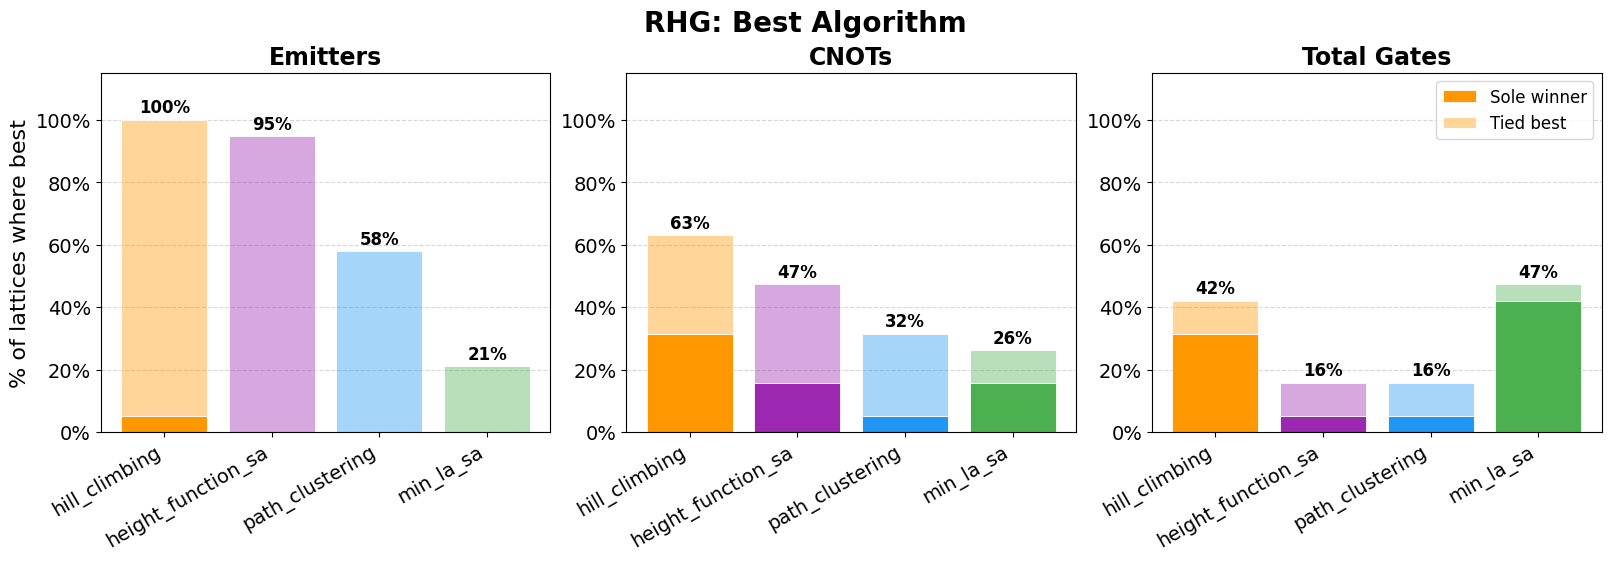

In [39]:
# ── Plot D  (RHG) — which algorithm wins most lattices per metric ─────────────

LABEL_SIZE = 16
TITLE_SIZE = 17
TICK_SIZE = 14
BAR_TEXT_SIZE = 12
LEGEND_SIZE = 12
SUPTITLE_SIZE = 20
XTICK_ROTATION = 30

METRICS_RHG = [
    ("emitters",  "Emitters"),
    ("cnots",     "CNOTs"),
    ("gates",     "Total Gates"),
]

nrows, ncols = 1, 3

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 5.5),
    sharey=False,
    constrained_layout=True
)

axes_flat = axes.flatten()

fig.suptitle(
    "RHG: Best Algorithm",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold"
)

for idx, ((metric, mlabel), ax) in enumerate(zip(METRICS_RHG, axes_flat)):
    wins = {a: 0 for a in ALGOS_RHG}
    ties = {a: 0 for a in ALGOS_RHG}
    n_compared = 0

    for graph_name in done_graphs_rhg:
        sub = df_rhg_done[df_rhg_done["graph"] == graph_name]

        vals = {
            row["algo"]: row[metric]
            for _, row in sub.iterrows()
            if pd.notna(row[metric])
        }

        if not vals:
            continue

        best = min(vals.values())

        winners = [
            a
            for a, v in vals.items()
            if v == best
        ]

        n_compared += 1

        for a in winners:
            if len(winners) == 1:
                wins[a] += 1
            else:
                ties[a] += 1

    pct_wins = [
        wins[a] / n_compared * 100 if n_compared else 0
        for a in ALGOS_RHG
    ]

    pct_ties = [
        ties[a] / n_compared * 100 if n_compared else 0
        for a in ALGOS_RHG
    ]

    x = np.arange(len(ALGOS_RHG))

    bars_w = ax.bar(
        x,
        pct_wins,
        color=ALGO_COLORS_RHG,
        edgecolor="white",
        linewidth=0.6,
        label="Sole winner"
    )

    bars_t = ax.bar(
        x,
        pct_ties,
        bottom=pct_wins,
        color=[c + "66" for c in ALGO_COLORS_RHG],
        edgecolor="white",
        linewidth=0.6,
        label="Tied best"
    )

    for bar, pw, pt in zip(bars_w, pct_wins, pct_ties):
        total = pw + pt

        if total > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                total + 1.0,
                f"{total:.0f}%",
                ha="center",
                va="bottom",
                fontsize=BAR_TEXT_SIZE,
                fontweight="bold"
            )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [ALGO_LABELS_RHG[a] for a in ALGOS_RHG],
        fontsize=TICK_SIZE,
        rotation=XTICK_ROTATION,
        ha="right"
    )

    ax.set_title(
        mlabel,
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    ax.set_ylabel(
        "% of lattices where best" if idx % ncols == 0 else "",
        fontsize=LABEL_SIZE
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    ax.set_axisbelow(True)

    if idx == len(METRICS_RHG) - 1:
        ax.legend(
            fontsize=LEGEND_SIZE,
            loc="upper right"
        )

plt.show()

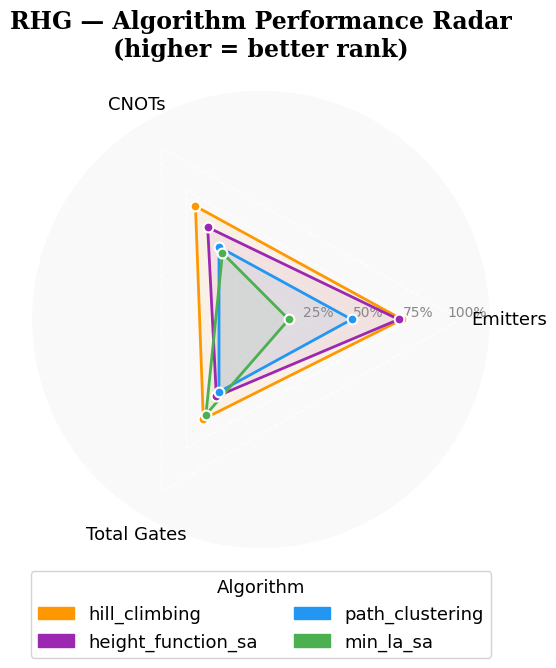

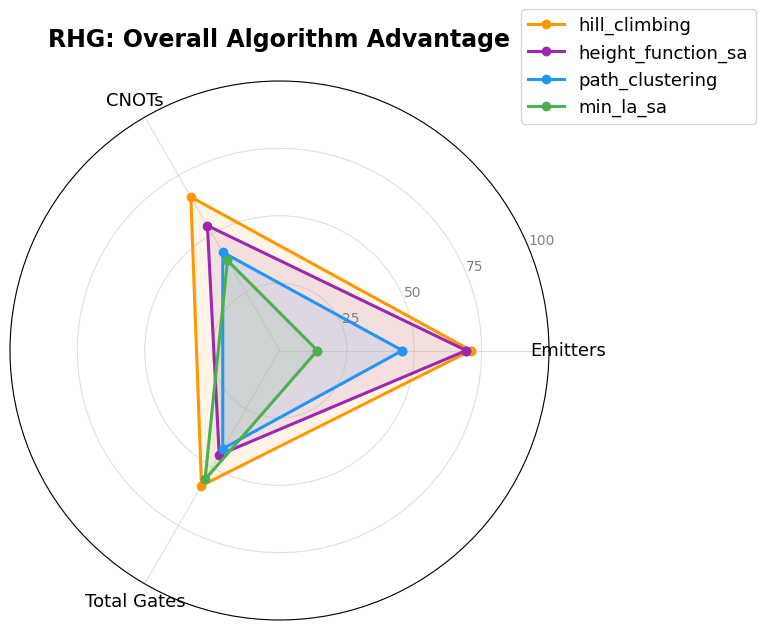

In [40]:
# ── Plot E  (RHG) — normalised radar chart ────────────────────────────────────

LABEL_SIZE = 15
TITLE_SIZE = 17
TICK_SIZE = 13
RADIAL_TICK_SIZE = 10
LEGEND_SIZE = 13
LEGEND_TITLE_SIZE = 13
REFERENCE_TEXT_SIZE = 10

radar_metrics_rhg = [m for m, _ in METRICS_RHG]
radar_labels_rhg = [l for _, l in METRICS_RHG]
N_rhg = len(radar_metrics_rhg)

rank_data_rhg = {a: [] for a in ALGOS_RHG}

for metric in radar_metrics_rhg:
    ranks_per_graph = []

    for graph_name in done_graphs_rhg:
        sub = df_rhg_done[df_rhg_done["graph"] == graph_name]

        vals = {
            row["algo"]: row[metric]
            for _, row in sub.iterrows()
            if pd.notna(row[metric])
        }

        if len(vals) < 2:
            continue

        sorted_algos = sorted(vals, key=lambda a: vals[a])

        rank_map = {}
        r = 1
        i = 0

        while i < len(sorted_algos):
            j = i

            while (
                j < len(sorted_algos) - 1
                and vals[sorted_algos[j + 1]] == vals[sorted_algos[j]]
            ):
                j += 1

            avg_r = (r + r + (j - i)) / 2

            for k in range(i, j + 1):
                rank_map[sorted_algos[k]] = avg_r

            r += (j - i + 1)
            i = j + 1

        ranks_per_graph.append(rank_map)

    for a in ALGOS_RHG:
        arr = [
            rg[a]
            for rg in ranks_per_graph
            if a in rg
        ]

        rank_data_rhg[a].append(
            np.mean(arr) if arr else np.nan
        )


def rank_to_score(rank):
    return (4 - rank) / 3 * 100  # 1 → 100%, 4 → 0%


# ═══════════════════════════════════════════════════════════════════
# Radar plot 1 — custom styled version
# ═══════════════════════════════════════════════════════════════════

angles_rhg = np.linspace(
    0,
    2 * np.pi,
    N_rhg,
    endpoint=False
).tolist()

angles_rhg += angles_rhg[:1]

fig = plt.figure(
    figsize=(7, 7),
    facecolor="white"
)

ax = fig.add_subplot(
    111,
    polar=True
)

ax.set_facecolor("#F9F9F9")

for ref in [25, 50, 75, 100]:
    ax.plot(
        angles_rhg,
        [ref] * (N_rhg + 1),
        color="white",
        linewidth=0.8,
        linestyle="--",
        zorder=1
    )

    ax.text(
        0,
        ref + 4,
        f"{ref}%",
        ha="center",
        va="bottom",
        fontsize=REFERENCE_TEXT_SIZE,
        color="#888888"
    )

ax.set_thetagrids(
    np.degrees(angles_rhg[:-1]),
    radar_labels_rhg,
    fontsize=LABEL_SIZE
)

ax.tick_params(
    axis="x",
    labelsize=TICK_SIZE
)

ax.set_ylim(0, 115)
ax.set_yticks([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

for a, color in zip(ALGOS_RHG, ALGO_COLORS_RHG):
    scores = [
        rank_to_score(r) if not np.isnan(r) else 0
        for r in rank_data_rhg[a]
    ]

    scores += scores[:1]

    ax.plot(
        angles_rhg,
        scores,
        color=color,
        linewidth=2,
        zorder=3
    )

    ax.fill(
        angles_rhg,
        scores,
        color=color,
        alpha=0.08,
        zorder=2
    )

    ax.scatter(
        angles_rhg[:-1],
        scores[:-1],
        color=color,
        s=50,
        zorder=4,
        edgecolors="white",
        linewidths=1.5
    )

ax.set_title(
    "RHG — Algorithm Performance Radar\n(higher = better rank)",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=25,
    fontfamily="serif"
)

handles = [
    mpatches.Patch(
        color=c,
        label=ALGO_LABELS_RHG[a]
    )
    for a, c in zip(ALGOS_RHG, ALGO_COLORS_RHG)
]

ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.26),
    ncol=2,
    fontsize=LEGEND_SIZE,
    framealpha=0.85,
    title="Algorithm",
    title_fontsize=LEGEND_TITLE_SIZE
)

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════
# Radar plot 2 — standard style matching original Plot E
# ═══════════════════════════════════════════════════════════════════

N_rhg = len(radar_labels_rhg)

angles_rhg = np.linspace(
    0,
    2 * np.pi,
    N_rhg,
    endpoint=False
).tolist()

angles_rhg += angles_rhg[:1]

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw=dict(polar=True)
)

for a, color in zip(ALGOS_RHG, ALGO_COLORS_RHG):
    scores = [
        rank_to_score(r) if not np.isnan(r) else 0
        for r in rank_data_rhg[a]
    ]

    scores += scores[:1]

    ax.plot(
        angles_rhg,
        scores,
        color=color,
        linewidth=2.2,
        label=ALGO_LABELS_RHG[a],
        marker="o",
        markersize=6
    )

    ax.fill(
        angles_rhg,
        scores,
        color=color,
        alpha=0.10
    )

ax.set_xticks(
    angles_rhg[:-1]
)

ax.set_xticklabels(
    radar_labels_rhg,
    fontsize=LABEL_SIZE
)

ax.tick_params(
    axis="x",
    labelsize=TICK_SIZE
)

ax.set_ylim(
    0,
    100
)

ax.set_yticks(
    [25, 50, 75, 100]
)

ax.set_yticklabels(
    ["25", "50", "75", "100"],
    fontsize=RADIAL_TICK_SIZE,
    color="grey"
)

ax.tick_params(
    axis="y",
    labelsize=RADIAL_TICK_SIZE
)

ax.set_title(
    "RHG: Overall Algorithm Advantage",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.40, 1.15),
    fontsize=LEGEND_SIZE
)

ax.grid(
    True,
    alpha=0.4
)

plt.show()

## LaTeX Table Export

Exports the QEC and RHG summary tables as `.tex` files ready for inclusion in a paper.
Run the cell below to (re-)generate `latex/table_qec.tex` and `latex/table_rhg.tex`.

In [41]:
# ── LaTeX export ──────────────────────────────────────────────────────────────
import pathlib

LATEX_OUT = pathlib.Path("latex")
LATEX_OUT.mkdir(exist_ok=True)


def _escape(s: str) -> str:
    """Escape LaTeX special characters in a string."""
    for ch, rep in [("_", r"\_"), ("#", r"\#"), ("%", r"\%"), ("&", r"\&")]:
        s = str(s).replace(ch, rep)
    return s


def df_to_latex(df_in: pd.DataFrame, caption: str, label: str) -> str:
    """Convert a plain DataFrame to a LaTeX longtable string."""
    cols = df_in.columns.tolist()
    n_cols = len(cols)
    col_spec = "l" + "r" * (n_cols - 1)   # first col left-aligned, rest right

    lines = [
        r"\begin{longtable}{" + col_spec + "}",
        r"  \caption{" + caption + r"} \label{" + label + r"} \\",
        r"  \toprule",
        "  " + " & ".join(f"\\textbf{{{_escape(c)}}}" for c in cols) + r" \\",
        r"  \midrule",
        r"  \endfirsthead",
        r"  \multicolumn{" + str(n_cols) + r"}{c}{\tablename\ \thetable{} (continued)} \\",
        r"  \toprule",
        "  " + " & ".join(f"\\textbf{{{_escape(c)}}}" for c in cols) + r" \\",
        r"  \midrule",
        r"  \endhead",
        r"  \midrule \multicolumn{" + str(n_cols) + r"}{r}{\textit{continued on next page}} \\",
        r"  \endfoot",
        r"  \bottomrule",
        r"  \endlastfoot",
    ]

    for _, row in df_in.iterrows():
        lines.append("  " + " & ".join(_escape(str(v)) for v in row.values) + r" \\")

    lines.append(r"\end{longtable}")
    return "\n".join(lines)


# ── QEC table ─────────────────────────────────────────────────────────────────
qec_tex_df = (
    df_done[["graph", "vertices", "edges", "algo", "emitters", "cnots", "gates"]]
    .copy()
    .sort_values(["vertices", "graph", "algo"])
    .reset_index(drop=True)
)
qec_tex_df["algo"] = qec_tex_df["algo"].map(ALGO_LABELS)
for col in ["emitters", "cnots", "gates"]:
    qec_tex_df[col] = qec_tex_df[col].apply(
        lambda v: str(int(v)) if pd.notna(v) else r"\textemdash"
    )
qec_tex_df.columns = ["Graph", "|V|", "|E|", "Algorithm", "Emitters", "CNOTs", "Gates"]

qec_tex = df_to_latex(
    qec_tex_df,
    caption=f"QEC benchmark results — {n_done} completed graphs × {len(ALGOS)} algorithms.",
    label="tab:qec_results",
)
(LATEX_OUT / "table_qec.tex").write_text(qec_tex)
print(f"Wrote {LATEX_OUT / 'table_qec.tex'}  ({len(qec_tex_df)} rows)")


# ── RHG table ─────────────────────────────────────────────────────────────────
rhg_tex_df = (
    df_rhg_done[["dims", "vertices", "edges", "algo",
                 "emitters", "cnots", "gates"]]
    .copy()
    .sort_values(["vertices", "algo"])
    .reset_index(drop=True)
)
rhg_tex_df["algo"] = rhg_tex_df["algo"].map(ALGO_LABELS_RHG)
rhg_tex_df["dims"] = rhg_tex_df["dims"].apply(lambda d: f"({d[0]},{d[1]},{d[2]})")
for col in ["emitters", "cnots", "gates"]:
    rhg_tex_df[col] = rhg_tex_df[col].apply(
        lambda v: str(int(v)) if pd.notna(v) else r"\textemdash"
    )
rhg_tex_df.columns = ["Dims", "|V|", "|E|", "Algorithm",
                      "Emitters", "CNOTs", "Gates"]

rhg_tex = df_to_latex(
    rhg_tex_df,
    caption=f"RHG lattice benchmark results — {n_done_rhg} completed lattices × {len(ALGOS_RHG)} algorithms.",
    label="tab:rhg_results",
)
(LATEX_OUT / "table_rhg.tex").write_text(rhg_tex)
print(f"Wrote {LATEX_OUT / 'table_rhg.tex'}  ({len(rhg_tex_df)} rows)")

print("\nInclude in LaTeX with:")
print(r"  \usepackage{longtable, booktabs}")
print(r"  \input{latex/table_qec.tex}")
print(r"  \input{latex/table_rhg.tex}")


Wrote latex/table_qec.tex  (160 rows)
Wrote latex/table_rhg.tex  (76 rows)

Include in LaTeX with:
  \usepackage{longtable, booktabs}
  \input{latex/table_qec.tex}
  \input{latex/table_rhg.tex}
